### CS24B2046 T.Kanishka
### LAB 3



### Question 1 

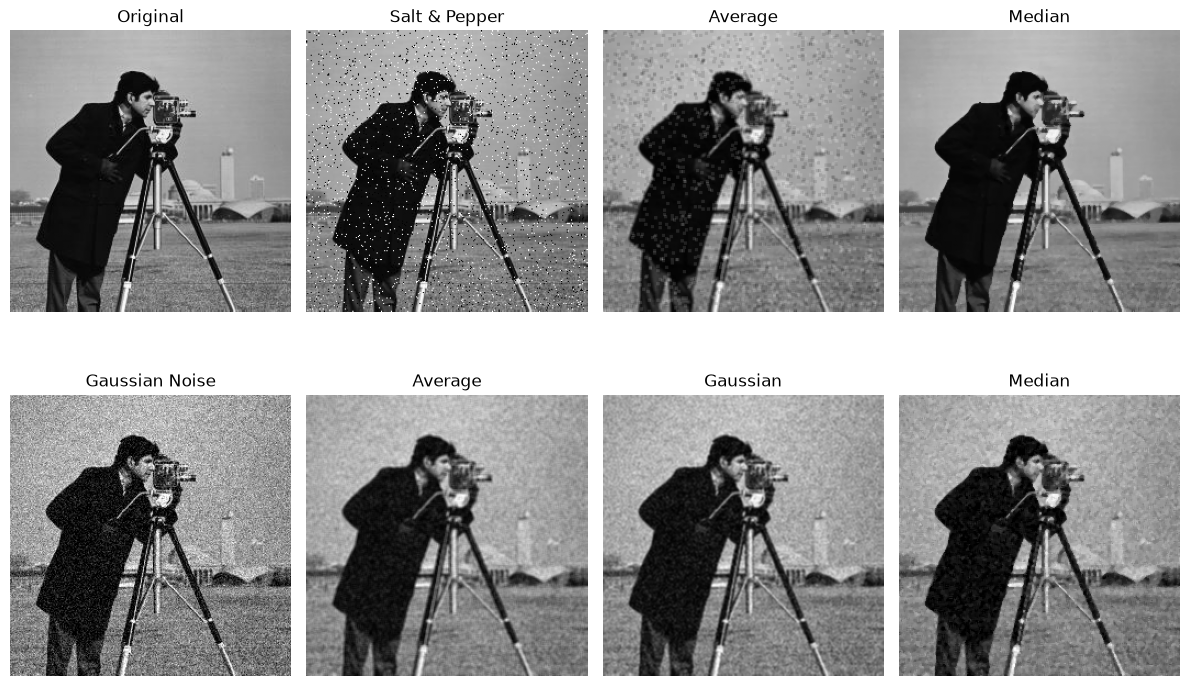

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("cameraman.jpg", cv2.IMREAD_GRAYSCALE)

# Add Gaussian noise
gaussian_noise = image.astype(np.float32) + np.random.normal(0, 25, image.shape)
gaussian_noise = np.clip(gaussian_noise, 0, 255).astype(np.uint8)

# Add Salt and Pepper noise
sp_noise = image.copy()
noise = np.random.rand(*image.shape)

sp_noise[noise < 0.025] = 0
sp_noise[noise > 0.975] = 255

# Apply filters on Salt and Pepper noise
average_sp = cv2.blur(sp_noise, (3, 3))
gaussian_sp = cv2.GaussianBlur(sp_noise, (3, 3), 0)
median_sp = cv2.medianBlur(sp_noise, 3)

# Apply filters on Gaussian noise
average_g = cv2.blur(gaussian_noise, (3, 3))
gaussian_g = cv2.GaussianBlur(gaussian_noise, (3, 3), 0)
median_g = cv2.medianBlur(gaussian_noise, 3)

# Display
plt.figure(figsize=(12, 8))

plt.subplot(2, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(2, 4, 2)
plt.imshow(sp_noise, cmap="gray")
plt.title("Salt & Pepper")
plt.axis("off")

plt.subplot(2, 4, 3)
plt.imshow(average_sp, cmap="gray")
plt.title("Average")
plt.axis("off")

plt.subplot(2, 4, 4)
plt.imshow(median_sp, cmap="gray")
plt.title("Median")
plt.axis("off")

plt.subplot(2, 4, 5)
plt.imshow(gaussian_noise, cmap="gray")
plt.title("Gaussian Noise")
plt.axis("off")

plt.subplot(2, 4, 6)
plt.imshow(average_g, cmap="gray")
plt.title("Average")
plt.axis("off")

plt.subplot(2, 4, 7)
plt.imshow(gaussian_g, cmap="gray")
plt.title("Gaussian")
plt.axis("off")

plt.subplot(2, 4, 8)
plt.imshow(median_g, cmap="gray")
plt.title("Median")
plt.axis("off")

plt.tight_layout()
plt.show()

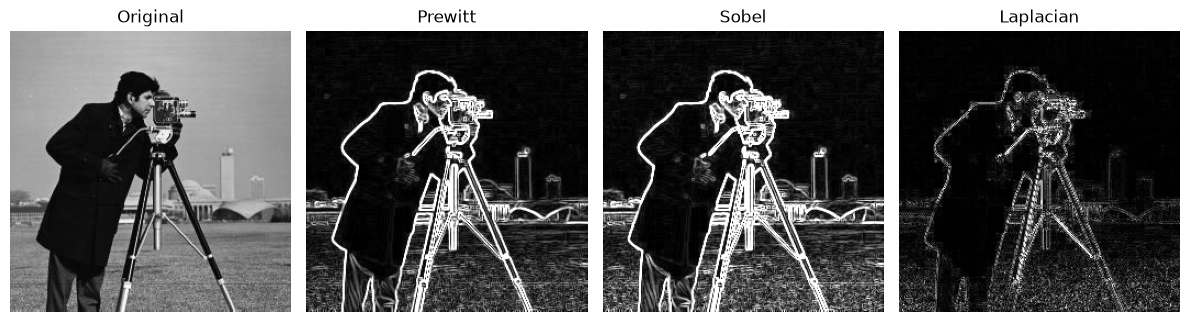

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
image = cv2.imread("cameraman.jpg", cv2.IMREAD_GRAYSCALE)

# Prewitt kernels
prewitt_x = np.array([
    [-1, 0, 1],
    [-1, 0, 1],
    [-1, 0, 1]
])

prewitt_y = np.array([
    [-1, -1, -1],
    [0, 0, 0],
    [1, 1, 1]
])

# Prewitt
px = cv2.filter2D(image, cv2.CV_32F, prewitt_x)
py = cv2.filter2D(image, cv2.CV_32F, prewitt_y)
prewitt = cv2.magnitude(px, py)
prewitt = cv2.convertScaleAbs(prewitt)

# Sobel
sx = cv2.Sobel(image, cv2.CV_32F, 1, 0, ksize=3)
sy = cv2.Sobel(image, cv2.CV_32F, 0, 1, ksize=3)
sobel = cv2.magnitude(sx, sy)
sobel = cv2.convertScaleAbs(sobel)

# Laplacian
laplacian = cv2.Laplacian(image, cv2.CV_32F)
laplacian = cv2.convertScaleAbs(laplacian)

# Display results
plt.figure(figsize=(12, 6))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 4, 2)
plt.imshow(prewitt, cmap="gray")
plt.title("Prewitt")
plt.axis("off")

plt.subplot(1, 4, 3)
plt.imshow(sobel, cmap="gray")
plt.title("Sobel")
plt.axis("off")

plt.subplot(1, 4, 4)
plt.imshow(laplacian, cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.tight_layout()
plt.show()